In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from IPython.display import display

import imagegen.fileutil as fu
import imagegen.data as data
import imagegen.vae as vae

In [20]:
fu.preview_slideshow("/Users/davidschneider/data/image/celeba/img_align_celeba", shuffle=0.3, delay=0.3, lim=20)

Done! Displayed 21 images.


In [17]:
files = data.get_files(directories=["/Users/davidschneider/data/image/celeba/img_align_celeba"], max_mb=100)

Discarding 188238 to stay under 100 MB data


In [18]:
len(files)

14361

In [21]:
ds = data.ImageDataset(files=files)

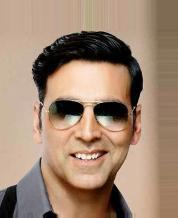

In [40]:
display(T.ToPILImage()(ds[1139]))

In [41]:
dl = data.get_celeb_ds()
en = vae.Encoder().to('mps')
dec = vae.Decoder().to('mps')
for x in dl:
    x = x.to('mps')
    z_mu, z_logsig = en(x)
    x_logits = dec(z_mu)
    break


In [42]:
x.size()

torch.Size([5, 3, 218, 178])

In [43]:
xprobs.size()

torch.Size([5, 116412, 256])

In [44]:
(116412*256*5)/1e6


149.00736

In [ ]:
def elbo(x, 